# Final Deliverable

**Author:** Stella Dong

*Department of Computer Science & Engineering, Texas A&M University*  
*This work was completed as part of CSCE 676: Data Mining and Analysis, taught by Prof. James Caverlee.*

The Github repository of this project can be found here: [Github link](https://github.com/stellasdong/676_project/).

---


## Background Information

### Dataset: [Texas Inpatient PUF](https://www.dshs.texas.gov/center-health-statistics/texas-health-care-information-collection/download-and-purchase-data/texas-inpatient-public-use-data-file-pudf/public-use-data-File-pudf-inpatient-free-download)

### Scope
The Texas Inpatient Public Use Data File (PUDF) is a publicly available dataset covering inpatient visits across ~700 Texas hospitals over all four quarters of 2019. Inpatient visits are those where a physician has admitted a patient to a facility for extended monitoring or treatment, so each record represents a higher-acuity episode of care. With over 3 million records statewide, this analysis is scoped to the Bryan-College Station (BCS) area — 4 facilities in Bryan and 2 in College Station that reported data for all four quarters.

### Variables
Although the PUDF contains no patient-identifiable information, it provides rich per-visit records across 167 variables, including a principal diagnosis and up to 24 additional diagnoses, length of stay, total charges, insurance type, and patient demographics.

### ICD-10-CM Codes and CCSR
Diagnoses in the PUDF are recorded using ICD-10-CM (International Classification of Diseases, 10th Revision, Clinical Modification) codes, the standardized coding system used across U.S. healthcare to document conditions, symptoms, and findings. ICD-10-CM contains over 70,000 codes, making direct analysis of co-occurrence patterns sparse and difficult to interpret.

To address this, diagnoses are mapped to the Clinical Classifications Software Refined (CCSR), developed by the Agency for Healthcare Research and Quality (AHRQ). CCSR aggregates ICD-10-CM codes into ~530 clinically meaningful categories, for example collapsing all hypertension codes into a single "Hypertensive disease" category. This dimensionality reduction yields denser co-occurrence patterns and results that are more interpretable without sacrificing clinical relevance.

---

## Research Direction

### Co-morbidities and Healthcare Resource Utilization
Co-morbidities is the co-occurrence of multiple diseases or conditions in a single patient. This can be something as straight-forward as diabetes and heart disease, or a combination of two very distinct conditions, like one mental health and one physical disorder. These patterns of multiple conditions can cause increasinglly worse health outcomes and increased healthcare costs for patients. Because this dataset contains up to 25 diagnoses codes per patient, this is a meaningful clinical topic that could easily be explored in this dataset.

### Research Questions
1. Which diagnosis codes most commonly co-occur in BCS inpatient visits, and do any unexpected associations emerge?
2. What distinct patient subgroups share similar comorbidity profiles among inpatients in the BCS area?
3. Which comorbidity profiles predict high charges or longer stays?

---

## Dataset and Initial Cleaning


### Setup

Dependencies are listed in `requirements.txt`. Key libraries used throughout this notebook:

| Library | Purpose |
|---|---|
| `pandas` / `numpy` | Data wrangling and numerical operations |
| `icdmappings` | ICD-10-CM → CCSR code translation |
| `mlxtend` | Apriori algorithm and association rule mining |
| `scikit-learn` / `scikit-learn-extra` | Clustering algorithms and evaluation metrics |
| `umap-learn` | Dimensionality reduction for cluster visualization |
| `hdbscan` | Density-based hierarchical clustering |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

from icdmappings import Mapper
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from sklearn.preprocessing import MultiLabelBinarizer

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Imports complete.')

Imports complete.


### Loading the Data

The BCS inpatient dataset was pre-filtered from the statewide Texas PUDF to retain only records from the 6 Bryan–College Station facilities that reported data across all four quarters of 2019. The CSV is loaded directly from Google Drive.

In [2]:
DATA_PATH = "/Users/stelladong/Library/CloudStorage/GoogleDrive-ssdong@tamu.edu/My Drive/bcs_tx_inpatient.csv"

bcs_tx_inpatient = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded: {bcs_tx_inpatient.shape[0]:,} rows × {bcs_tx_inpatient.shape[1]} columns")
print(f"\nColumn preview:\n{list(bcs_tx_inpatient.columns[:10])} ...")

Loaded: 12,179 rows × 169 columns

Column preview:
['Unnamed: 0', 'RECORD_ID', 'DISCHARGE', 'THCIC_ID', 'TYPE_OF_ADMISSION', 'SOURCE_OF_ADMISSION', 'SPEC_UNIT_1', 'SPEC_UNIT_2', 'SPEC_UNIT_3', 'SPEC_UNIT_4'] ...


In [ ]:
# --- Patient demographics: age, sex, race distributions ---
AGE_LABELS = {
    0: '<1', 1: '1–4', 2: '5–9', 3: '10–14', 4: '15–17', 5: '18–19',
    6: '20–24', 7: '25–29', 8: '30–34', 9: '35–39', 10: '40–44',
    11: '45–49', 12: '50–54', 13: '55–59', 14: '60–64', 15: '65–69',
    16: '70–74', 17: '75–79', 18: '80–84', 19: '85–89', 20: '90+',
}
RACE_LABELS = {1: 'White', 2: 'Black', 3: 'Hispanic', 4: 'Other', 5: 'Unknown'}
SEX_LABELS  = {'F': 'Female', 'M': 'Male'}

age_counts  = (bcs_tx_inpatient['PAT_AGE']
               .value_counts().sort_index()
               .rename(index=lambda x: AGE_LABELS.get(x, str(x))))
sex_counts  = (bcs_tx_inpatient['SEX_CODE']
               .value_counts()
               .rename(index=lambda x: SEX_LABELS.get(x, str(x))))
race_counts = (bcs_tx_inpatient['RACE']
               .value_counts().sort_index()
               .rename(index=lambda x: RACE_LABELS.get(x, str(x))))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(age_counts.index, age_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Patients')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(sex_counts.index, sex_counts.values, color='steelblue', edgecolor='white')
axes[1].set_title('Sex Distribution')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Number of Patients')
for bar, val in zip(axes[1].patches, sex_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

axes[2].bar(race_counts.index, race_counts.values, color='steelblue', edgecolor='white')
axes[2].set_title('Race/Ethnicity Distribution')
axes[2].set_xlabel('Race/Ethnicity')
axes[2].set_ylabel('Number of Patients')

fig.suptitle('BCS Inpatient Population Demographics, 2019', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### ICD-10-CM to CCSR Mapping

Each of the 25 possible diagnosis columns is mapped from its raw ICD-10-CM code to a CCSR category using the `icdmappings` library. Codes that cannot be mapped (e.g., malformed entries or codes not present in the CCSR reference) are dropped. Mapping is performed in batches over only the unique codes observed in the dataset to avoid redundant lookups.

This step reduces the raw ICD-10-CM space (70 000+ codes) to ~530 clinically meaningful CCSR categories, yielding denser co-occurrence patterns that are easier to mine and interpret.

In [3]:
df = bcs_tx_inpatient.copy()

# Identify diagnosis columns present in the dataframe
DIAG_COLS = [c for c in
             ['PRINC_DIAG_CODE'] + [f'OTH_DIAG_CODE_{i}' for i in range(1, 25)]
             if c in df.columns]

# Collect all unique ICD-10 codes across all diagnosis columns
all_codes = set()
for col in DIAG_COLS:
    all_codes.update(df[col].dropna().unique())
all_codes = list(all_codes)
print(f"Unique ICD-10-CM codes in dataset: {len(all_codes):,}")

# Map each unique ICD-10-CM code to its CCSR category in batches
BATCH_SIZE = 10_000
mapper = Mapper()
ccsr_mapping = {}

for i in range(0, len(all_codes), BATCH_SIZE):
    batch = all_codes[i : i + BATCH_SIZE]
    results = mapper.map(batch, source='icd10', target='ccsr')
    for code, ccsr in zip(batch, results):
        ccsr_mapping[code] = ccsr  # None if unmappable

mapped = sum(1 for v in ccsr_mapping.values() if v is not None)
unique_ccsr = len(set(v for v in ccsr_mapping.values() if v is not None))
print(f"Successfully mapped: {mapped:,} / {len(ccsr_mapping):,} codes "
      f"({mapped / len(ccsr_mapping) * 100:.1f}%)")
print(f"Unique CCSR categories: {unique_ccsr:,}  "
      f"(reduced from {len(all_codes):,} ICD-10-CM codes, "
      f"{len(all_codes) / unique_ccsr:.0f}× reduction)")

Unique ICD-10-CM codes in dataset: 5,512
Successfully mapped: 5,512 / 5,512 codes (100.0%)
Unique CCSR categories: 440  (reduced from 5,512 ICD-10-CM codes, 13× reduction)


### Patient–CCSR Binary Encoding

Each patient visit is represented as a binary vector over all observed CCSR categories: a `1` in position `j` means the patient received at least one diagnosis belonging to CCSR category `j`; `0` means they did not. This binary matrix is the primary input to all downstream clustering analyses.

The resulting matrix has one row per patient and one column per CCSR category, yielding a sparse representation that captures each patient's full comorbidity profile in a form amenable to distance-based and set-based similarity measures.

In [4]:
# --- Binary CCSR encoding ---
# For each patient (row), collect the set of CCSR categories present across
# all diagnosis columns, then one-hot encode into a binary matrix.

def get_ccsr_set(row):
    cats = set()
    for col in DIAG_COLS:
        code = row[col]
        if pd.notna(code):
            ccsr = ccsr_mapping.get(code)
            if ccsr is not None:
                cats.add(ccsr)
    return list(cats)

# Build list-of-lists: one entry per patient
ccsr_lists = df.apply(get_ccsr_set, axis=1).tolist()

# Fit MultiLabelBinarizer on all observed CCSR categories
mlb = MultiLabelBinarizer()
X_ccsr_binary = mlb.fit_transform(ccsr_lists)

print(f"Binary CCSR matrix shape: {X_ccsr_binary.shape}")
print(f"  Patients      : {X_ccsr_binary.shape[0]:,}")
print(f"  CCSR categories: {X_ccsr_binary.shape[1]:,}")
print(f"  Sparsity       : {1 - X_ccsr_binary.mean():.1%}")
print(f"\nCCSR category names (first 10): {mlb.classes_[:10].tolist()}")

Binary CCSR matrix shape: (12179, 440)
  Patients      : 12,179
  CCSR categories: 440
  Sparsity       : 97.9%

CCSR category names (first 10): ['BLD001', 'BLD002', 'BLD003', 'BLD004', 'BLD005', 'BLD006', 'BLD007', 'BLD008', 'BLD010', 'CIR001']


## Research Question 1: Which diagnosis codes most commonly co-occur?

This section mines comorbidity patterns from the BCS inpatient dataset using the Apriori algorithm applied to CCSR-encoded patient visits. The goal is to identify pairs (or larger sets) of diagnosis categories that co-occur more often than expected by chance.

---

### Exploratory Data Analysis

Before mining association rules, we explore the diagnosis structure of the dataset: how many codes are recorded per visit, and which CCSR categories appear most frequently. This motivates the choice of support threshold and highlights the most prevalent conditions in the BCS inpatient population.

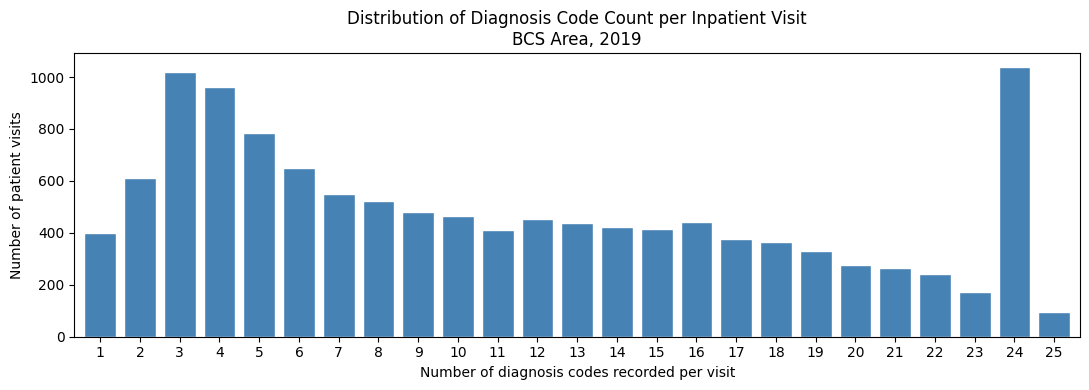

Mean diagnoses per visit  : 11.1
Median                    : 10
Max                       : 25
Visits with ≥ 2 diagnoses : 11,781  (96.7%)


In [5]:
# --- Distribution of diagnosis count per patient visit ---
diag_counts = df[DIAG_COLS].notna().sum(axis=1)

fig, ax = plt.subplots(figsize=(11, 4))
diag_counts.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', width=0.8)
ax.set_xlabel("Number of diagnosis codes recorded per visit")
ax.set_ylabel("Number of patient visits")
ax.set_title("Distribution of Diagnosis Code Count per Inpatient Visit\nBCS Area, 2019")
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print(f"Mean diagnoses per visit  : {diag_counts.mean():.1f}")
print(f"Median                    : {int(diag_counts.median())}")
print(f"Max                       : {int(diag_counts.max())}")
print(f"Visits with ≥ 2 diagnoses : {(diag_counts >= 2).sum():,}  ({(diag_counts >= 2).mean()*100:.1f}%)")

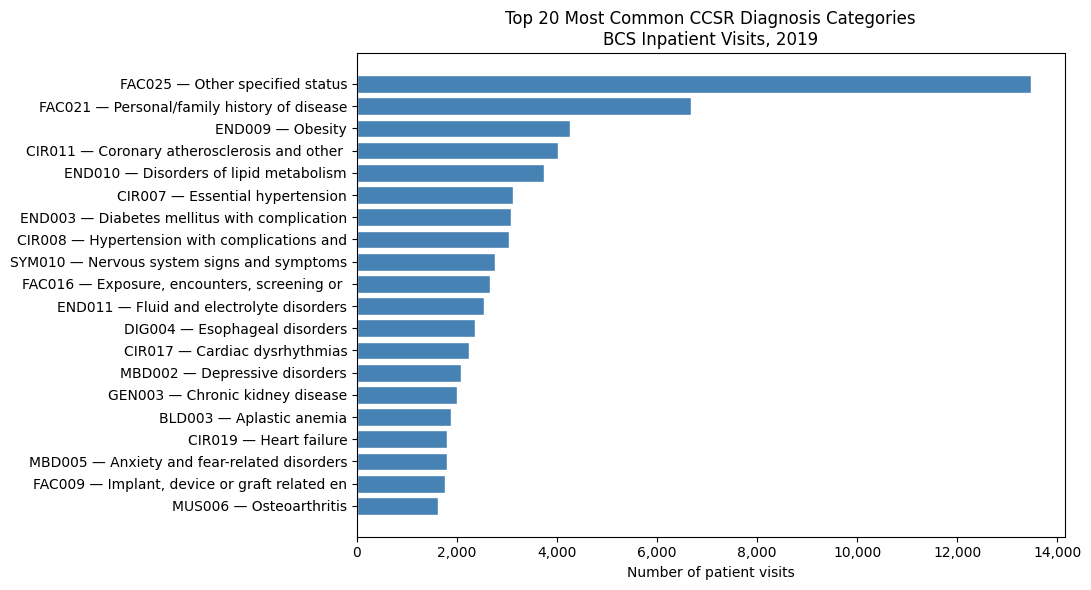

In [6]:
# --- Top 20 most common CCSR categories ---
CCSR_DESC_PATH = "/Users/stelladong/Documents/GitHub/676_project/ccsr_descriptions.txt"
ccsr_desc = {}
with open(CCSR_DESC_PATH) as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            ccsr_desc[parts[0]] = parts[1]

ccsr_counter = Counter()
for col in DIAG_COLS:
    for code in df[col].dropna():
        ccsr = ccsr_mapping.get(code)
        if ccsr is not None:
            ccsr_counter[ccsr] += 1

top20 = pd.DataFrame(ccsr_counter.most_common(20), columns=['ccsr', 'count'])
top20['label'] = top20['ccsr'].apply(
    lambda c: f"{c} — {ccsr_desc.get(c, c)[:35]}"
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top20['label'][::-1], top20['count'][::-1], color='steelblue', edgecolor='white')
ax.set_xlabel("Number of patient visits")
ax.set_title("Top 20 Most Common CCSR Diagnosis Categories\nBCS Inpatient Visits, 2019")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**Key observations:**

**Comorbidity prevalence.** Over 96% of inpatient visits have more than one recorded diagnosis, confirming that comorbidity is the rule rather than the exception in this population. The median visit carries multiple distinct CCSR conditions, which justifies applying association rule mining rather than treating diagnoses in isolation.

**Top diagnosis categories.** The top 20 CCSR categories reveal three dominant groupa:

- Cardiovascular-metabolic cluster: Essential hypertension (CIR007), hypertension with complications (CIR008), coronary atherosclerosis (CIR011), heart failure (CIR019), disorders of lipid metabolism (END010), and diabetes mellitus with complications (END003) all rank among the most common categories. These conditions are well-known to co-occur.

- Chronic disease management codes: Categories such as chronic kidney disease (GEN003) and "other specified status" (FAC025 — a catch-all for chronic disease monitoring flags like long-term medication use) appear frequently as secondary diagnoses, indicating that many admissions involve patients managing multiple long-term conditions alongside their primary presenting complaint.

- Mental health disorder codes: Depressive disorders (MDB002) and anxiety and fear-related disorders (MBD005) are also present in the top 20 categories, although less high on the list than the other major groups. 

### Association Rule Mining

Association rule mining treats each patient visit as a "basket" of CCSR categories and searches for rules of the form *A → B* — if a patient has condition A, they also tend to have condition B. 

The Apriori algorithm is used with `min_support = 0.05` (at least 5% of visits) and `min_confidence = 0.50`.

In [7]:
# Reuse ccsr_lists computed during binary encoding
ccsr_transactions = [t for t in ccsr_lists if len(t) > 0]
print(f"Transactions : {len(ccsr_transactions):,} patients")
print(f"Avg CCSR categories per patient: {np.mean([len(t) for t in ccsr_transactions]):.1f}")

# Encode as a boolean DataFrame required by mlxtend
te = TransactionEncoder()
te_array = te.fit_transform(ccsr_transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)
print(f"Unique CCSR categories in transactions: {df_te.shape[1]}")

# --- Frequent itemsets ---
MIN_SUPPORT = 0.05      # at least 5% of patients
frequent_itemsets = apriori(df_te, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
print(f"\nFrequent itemsets (support ≥ {MIN_SUPPORT}): {len(frequent_itemsets):,}")
print(frequent_itemsets.sort_values('support', ascending=False).head(10).to_string(index=False))

# --- Association rules ---
MIN_CONFIDENCE = 0.5
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=MIN_CONFIDENCE)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)
print(f"\nAssociation rules (confidence ≥ {MIN_CONFIDENCE}): {len(rules):,}")

Transactions : 12,179 patients
Avg CCSR categories per patient: 9.1
Unique CCSR categories in transactions: 440

Frequent itemsets (support ≥ 0.05): 306
 support                    itemsets  length
0.496100         frozenset({FAC025})       1
0.377289         frozenset({FAC021})       1
0.296083         frozenset({END010})       1
0.271040 frozenset({FAC025, FAC021})       2
0.256507         frozenset({CIR007})       1
0.237376         frozenset({CIR008})       1
0.235816 frozenset({FAC025, END010})       2
0.196486 frozenset({CIR008, FAC025})       2
0.196157         frozenset({END009})       1
0.189342         frozenset({CIR011})       1

Association rules (confidence ≥ 0.5): 559


### Top Comorbidity Rules

Rules are ranked by **lift** — the ratio of observed co-occurrence to what would be expected if the two conditions were independent. A lift of 1.0 means no association; higher values indicate increasingly strong co-occurrence beyond chance. Rules with lift ≥ 2.0 are considered strong associations and are highlighted for further analysis.

Inspecting the top rules by lift immediately reveals that the highest-scoring associations (lift ~7.9–8.1) are dominated by **pregnancy-related (PRG) and perinatal/neonatal (PNL) codes**. For example:

- *PRG002 (Gestational weeks) + PRG026 (OB-related trauma) → PRG030 (Maternal outcome of delivery)* — lift 8.09
- *PNL001 (Liveborn) ↔ FAC016 + PNL007 (Hemolytic jaundice)* — lift 8.00

These are not clinically interesting comorbidities — they co-occur by definition within obstetric and neonatal admissions, where multiple obstetric codes are routinely co-assigned to the same visit. Their high lift reflects the structural coding conventions of labor and delivery records, not a meaningful disease association.

In [8]:
def describe_set(frozen_set):
    return ' | '.join(f"{c}: {ccsr_desc.get(c, c)}" for c in sorted(frozen_set))

# Filter to high-lift rules and add human-readable labels
HIGH_LIFT = 2.0
high_score_rules = rules[rules['lift'] >= HIGH_LIFT].copy()

high_score_rules['antecedent_codes']  = high_score_rules['antecedents'].apply(lambda s: ' | '.join(sorted(s)))
high_score_rules['antecedent_labels'] = high_score_rules['antecedents'].apply(describe_set)
high_score_rules['consequent_codes']  = high_score_rules['consequents'].apply(lambda s: ' | '.join(sorted(s)))
high_score_rules['consequent_labels'] = high_score_rules['consequents'].apply(describe_set)

export_cols = [
    'antecedent_codes', 'antecedent_labels',
    'consequent_codes', 'consequent_labels',
    'support', 'confidence', 'lift',
]
export_df = (high_score_rules[export_cols]
             .sort_values('lift', ascending=False)
             .reset_index(drop=True))
export_df[['support', 'confidence', 'lift']] = export_df[['support', 'confidence', 'lift']].round(4)

print(f"High-scoring rules (lift ≥ {HIGH_LIFT}): {len(export_df):,}\n")
display(export_df.head(15))

High-scoring rules (lift ≥ 2.0): 346



,antecedent_codes,antecedent_labels,consequent_codes,consequent_labels,support,confidence,lift
0,PRG002 | PRG026,PRG002: Gestational weeks | PRG026: OB-related...,PRG030,PRG030: Maternal outcome of delivery,0.0525,1.0000,8.0870
1,PRG026,PRG026: OB-related trauma to perineum and vulva,PRG002 | PRG030,PRG002: Gestational weeks | PRG030: Maternal o...,0.0525,0.9938,8.0797
2,PRG026,PRG026: OB-related trauma to perineum and vulva,PRG030,PRG030: Maternal outcome of delivery,0.0528,0.9984,8.0744
3,PRG002 | PRG023,PRG002: Gestational weeks | PRG023: Complicati...,PRG030,PRG030: Maternal outcome of delivery,0.0669,0.9927,8.0279
4,PRG030,PRG030: Maternal outcome of delivery,PRG002 | PRG023,PRG002: Gestational weeks | PRG023: Complicati...,0.0669,0.5412,8.0279
5,PRG023,PRG023: Complications specified during childbirth,PRG002 | PRG030,PRG002: Gestational weeks | PRG030: Maternal o...,0.0669,0.9855,8.0122
6,PRG002 | PRG030,PRG002: Gestational weeks | PRG030: Maternal o...,PRG023,PRG023: Complications specified during childbirth,0.0669,0.5441,8.0122
7,PRG030,PRG030: Maternal outcome of delivery,PRG023,PRG023: Complications specified during childbirth,0.0672,0.5438,8.0088
8,PRG023,PRG023: Complications specified during childbirth,PRG030,PRG030: Maternal outcome of delivery,0.0672,0.9903,8.0088
9,PNL001,PNL001: Liveborn,FAC016 | PNL007,"FAC016: Exposure, encounters, screening or con...",0.0874,0.7060,7.9989


### Filtering PRG/PNL Codes

Because obstetric and neonatal codes co-occur by administrative coding convention rather than clinical comorbidity, rules where **both** the antecedent and consequent consist entirely of PRG or PNL codes are removed. Of the 346 high-lift rules (lift ≥ 2.0), **23 are removed**, leaving 323 rules that reflect genuine disease co-occurrence patterns.

In [ ]:
# --- Export rules excluding those where PRG/PNL codes appear on BOTH sides ---
# PRG = pregnancy-related, PNL = perinatal/neonatal — rules where both antecedent
# and consequent are purely obstetric/neonatal are clinically uninteresting.

def has_prg_or_pnl(frozen_set):
    return any(c.startswith('PRG') or c.startswith('PNL') for c in frozen_set)

mask = ~(high_score_rules['antecedents'].apply(has_prg_or_pnl) &
         high_score_rules['consequents'].apply(has_prg_or_pnl))
filtered_rules = high_score_rules[mask].copy()

export_df_filtered = (filtered_rules[export_cols]
                      .sort_values('lift', ascending=False)
                      .reset_index(drop=True))
export_df_filtered[['support', 'confidence', 'lift']] = (
    export_df_filtered[['support', 'confidence', 'lift']].round(4)
)

OUT_PATH = "/Users/stelladong/Documents/GitHub/676_project/comorbidity_rules_no_prg_pnl.csv"
export_df_filtered.to_csv(OUT_PATH, index=False)

print(f"Rules before filter : {len(export_df):,}")
print(f"Rules after filter  : {len(export_df_filtered):,}  (removed {len(export_df)-len(export_df_filtered):,} PRG/PNL-only rules)")
print(f"Saved → {OUT_PATH}\n")
display(export_df_filtered.head(15))

### Key Observations

**Research Question 1: Which diagnosis codes most commonly co-occur?**

Before filtering, the highest-lift associations in the dataset are pregnancy-related (PRG) and perinatal/neonatal (PNL) codes. After removing rules where both sides are purely obstetric/neonatal, the strongest genuine comorbidity associations center on a tight cluster cardiometabolic disorders. The top-ranked rule by lift is the bidirectional association between: {CIR008 (Hypertension w/ complications) + END003 (Diabetes w/ complication)} and {END010 (Disorders of lipid metabolism) + GEN003 (Chronic kidney disease) + FAC025 (Other specified status)} (lift = 6.05).

Nearly every rule with a lift over 2.0 is a different directional or combinatorial slice of the same six-code group:

| Code | Description | Role |
|---|---|---|
| CIR008 | Hypertension with complications | Hub — appears in 248 rules |
| END010 | Disorders of lipid metabolism | Hub — appears in 182 rules |
| FAC025 | Other specified status (long-term meds/chronic monitoring) | Connector — 179 rules |
| GEN003 | Chronic kidney disease | Downstream target — 138 rules |
| CIR019 | Heart failure | Downstream target — 101 rules |
| CIR011 | Coronary atherosclerosis | Bidirectional — 96 rules |
| END003 | Diabetes mellitus with complication | Bidirectional — 76 rules |

This is consistent with the clinical concept of **metabolic syndrome**, where insulin resistance links hypertension, dyslipidemia, and diabetes, each of which progressively drives cardiovascular and renal damage.

**Secondary patterns:**

- **Dysrhythmia → Heart failure (lift 5.21).** CIR017 (Cardiac dysrhythmias) + CIR008 strongly predicts CIR019 (Heart failure), consistent with atrial fibrillation being both a driver and complication of heart failure.
- **Anemia–CKD link (lift ~5.0).** BLD003 (Aplastic anemia) + CIR008 strongly predicts GEN003 (CKD), reflecting anemia of chronic kidney disease.
- **Perinatal co-assignments (lift ~5.2–5.4).** Rules like PNL001 (Liveborn) ↔ FAC016 (Exposure/screening) remain in the filtered set because only one side is a PNL code. These are not meaningful comorbidities — they reflect routine neonatal admission coding practices.
- **No cross-system surprises.** Codes outside the cardiovascular-endocrine-renal axis (a few DIG and RSP codes) appear only at lower lift values and in fewer than 10 rules each, indicating that the BCS inpatient comorbidity burden is overwhelmingly concentrated in chronic metabolic and cardiovascular disease.